<img src="https://drive.google.com/uc?export=view&id=1Y-EIpLOigI9ycCOZRrRSFzAfuN9cxhqT" alt="Hobot Academy" width="300" height="300">

<h1 align="center"><font size="14">Hands-On Machine Learning</font></h1>
<h3 align="center"><font size="7">Session25: Outlier</font></h3>
<h3 align="center">Zahra Amini</h3>

In [1]:
from sklearn.datasets import make_moons, make_blobs
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn import svm

In [2]:
n_samples = 300

In [3]:
blobs_params = dict(n_samples=255 , n_features=2 , random_state=0 )

In [4]:
datasets = [
    make_blobs(centers=[[0, 0], [0, 0]]  , cluster_std=0.5       , **blobs_params)[0],
    make_blobs(centers=[[2, 2], [-2, -2]], cluster_std=[0.5, 0.5], **blobs_params)[0],
    make_blobs(centers=[[2, 2], [-2, -2]], cluster_std=[1.5, .3] , **blobs_params)[0],
    4. * (make_moons(n_samples=n_samples, noise=.05, random_state=0)[0] -np.array([0.5, 0.25])),
    14. * (np.random.RandomState(42).rand(n_samples, 2) - 0.5)
]

In [5]:
outliers_f = 0.15

n_out = int(outliers_f * n_samples)

n_in = n_samples - n_out

In [6]:
model = svm.OneClassSVM(kernel="rbf", nu=outliers_f, gamma=0.1)

In [7]:
anomaly = [("One-Class SVM", model)]

C:\Users\amini\AppData\Local\Temp\ipykernel_14556\3324420306.py:21: UserWarning: The following kwargs were not used by contour: 'color'
  plt.contour(xx, yy, Z, levels=[0], linewidths=2, color='black')
C:\Users\amini\AppData\Local\Temp\ipykernel_14556\3324420306.py:21: UserWarning: The following kwargs were not used by contour: 'color'
  plt.contour(xx, yy, Z, levels=[0], linewidths=2, color='black')
C:\Users\amini\AppData\Local\Temp\ipykernel_14556\3324420306.py:21: UserWarning: The following kwargs were not used by contour: 'color'
  plt.contour(xx, yy, Z, levels=[0], linewidths=2, color='black')
C:\Users\amini\AppData\Local\Temp\ipykernel_14556\3324420306.py:21: UserWarning: The following kwargs were not used by contour: 'color'
  plt.contour(xx, yy, Z, levels=[0], linewidths=2, color='black')
C:\Users\amini\AppData\Local\Temp\ipykernel_14556\3324420306.py:21: UserWarning: The following kwargs were not used by contour: 'color'
  plt.contour(xx, yy, Z, levels=[0], linewidths=2, color

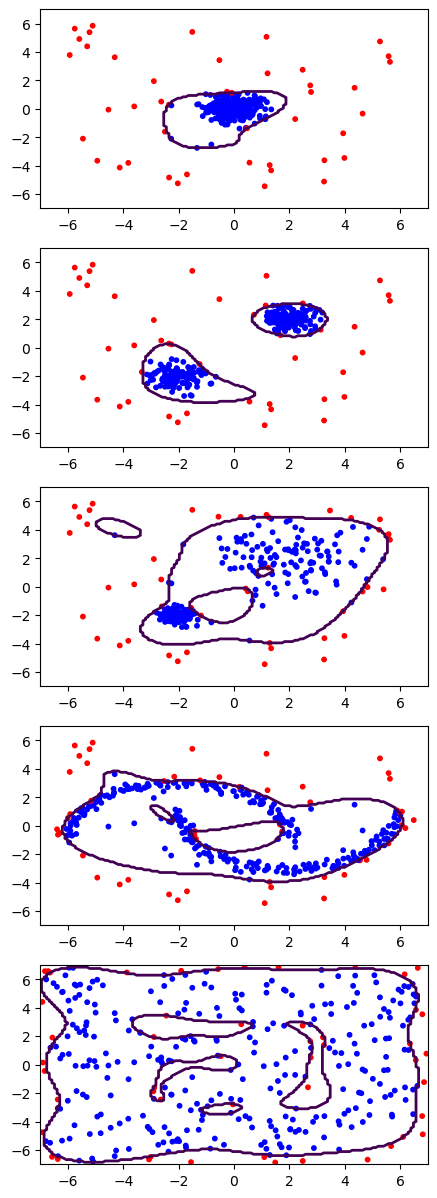

In [8]:
plt.figure(figsize=(5, 15))

plot_num = 1

xx, yy = np.meshgrid(np.linspace(-7, 7, 150), np.linspace(-7, 7, 150))

for i, X in enumerate(datasets):
    
    X = np.concatenate([X, np.random.RandomState(42).uniform(low=-6, high=6, size=(n_out, 2))], axis=0)
    
    for name, algorithm in anomaly:
        algorithm.fit(X)
        plt.subplot(len(datasets), len(anomaly), plot_num)
        
        y_pred = algorithm.fit(X).predict(X)
        
        Z = algorithm.predict(np.c_[xx.ravel(), yy.ravel()])
        
        Z = Z.reshape(xx.shape)
        
        plt.contour(xx, yy, Z, levels=[0], linewidths=2, color='black')
        
        colors = np.array(['r', 'b'])
        
        plt.scatter(X[:, 0], X[:, 1], s=10, color=colors[(y_pred+1)//2])
        
        plot_num  += 1
        
        

# Finished!